In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from typing import *
from pathlib import Path
import json
import gc
import math

from tqdm import tqdm
import torch
from torch import Tensor, nn

from Bio import Phylo
import numpy as np
import scipy
import pandas as pd
import gem
import matplotlib.pyplot as plt
import seaborn as sb
import sys


from gem.datasets import AbstractMetaphlanPreembeddedDataset, TorchStackedMetaphlanPreembeddedDataset, MetaphlanProfileParser, MetaphlanProfile
from gem.ml import SGBAbundancePredictionModel, SGBAbundanceLayeredPredictionModel, SGBEmbedPoolConcatPredictionModel, safe_kl_div_loss, HierarchicalSetTransformer

# Baseline predictors

In [3]:
class BaselinePredictor:
    def predict_abundances(self, sgb_ids: List[str]) -> np.ndarray:
        raise NotImplementedError()

## Uniform Abundance

In [4]:
""" Class definition. """
class UniformAbundancePredictor(BaselinePredictor):
    def __init__(self):
        pass

    def predict_abundances(self, sgb_ids: List[str]) -> np.ndarray:
        """ Compute output. """
        pred = np.ones(len(sgb_ids), dtype=float)
        pred = pred / np.sum(pred)
        return pred

## nearest-neighbor

### Implementation

In [5]:
""" Class definition. """
class NearestNeighborSGBFinder:
    def __init__(self, matrix_file: Path, database_sgbs: List[str]):
        data = np.load(matrix_file)
        all_sgbs = data['labels']
        dist_mat = data['mat']

        all_sgb_set = set(all_sgbs)
        for sgb_id in database_sgbs:
            if sgb_id not in all_sgb_set:
                print(f"[WARNING] SGB {sgb_id} not found in distance matrix. It probably lacks PhyloPhlAn markers and was excluded from the tree.")
        database_sgbs = [x for x in database_sgbs if x in all_sgb_set]

        all_sgb_indices = {lbl: i for i, lbl in enumerate(all_sgbs)}
        db_sgb_indices = {lbl: i for i, lbl in enumerate(database_sgbs)}

        db_matrix_indices = [all_sgb_indices[lbl] for lbl in database_sgbs]
        self.submatrix = dist_mat[:, db_matrix_indices]
        self.db_sgb_indices = db_sgb_indices
        self.db_sgb_order = database_sgbs
        self.query_sgb_indices = all_sgb_indices

    def __contains__(self, sgb_id: str) -> bool:
        return sgb_id in self.query_sgb_indices

    def nearest_neighbor(self, query_sgb_id: str) -> str:
        assert query_sgb_id in self.query_sgb_indices, f"Query SGB {query_sgb_id} is not in the query set!"
        query_idx = self.query_sgb_indices[query_sgb_id]
        query_row = self.submatrix[query_idx, :]
        nn_idx = np.argmin(query_row)
        return self.db_sgb_order[nn_idx]


def geom_mean_2d_column_nonzero(A: np.ndarray) -> np.ndarray:
    """
    For each column of a 2-d array A, compute the geometric mean of only nonzero entries (of that column).
    """
    mask = A != 0                            # Mask for nonzero entries
    counts = mask.sum(axis=0)                # Count nonzero entries per column
    A_safe = np.where(mask, A, 1)            # To avoid log(0): temporarily replace zeros with 1 (log(1) = 0, and they are masked anyway)
    log_sums = np.log(A_safe).sum(axis=0)    # Sum of logs over nonzero entries per column
    geom_means = np.exp(log_sums / counts)   # Geometric mean = exp( sum(log(x_i)) / count )
    geom_means[counts == 0] = np.nan         # If a column has no nonzero entries, set the geom mean to np.nan
    return geom_means


class NearestNeighborAveragingPredictorInner(BaselinePredictor):
    """
    Predict an abundance by assigning a weight to each SGB in the specified query sample.
    The weight of SGB "X" is equal to the geometric mean of the abundance of NearestNeighbor(X) in the training samples, or possibly the k-nearest training samples.

    Note: If "X" itself is in the training sample, then NearestNeighbor(X) = X, so we are counting the abundnaces of "X" itself in the training set.
    """
    def __init__(
            self,
            matrix_file: Path,
            train_samples: List[MetaphlanProfile]
    ):
        print("Initializing Nearest Neighbor predictor on {} training samples.".format(len(train_samples)))
        assert len(train_samples) > 0

        training_sgb_id_set = set()
        for sample in train_samples:
            training_sgb_id_set.update(sample.taxa_ids)

        self.training_sgbs = sorted(training_sgb_id_set)
        self.nn_finder = NearestNeighborSGBFinder(matrix_file, self.training_sgbs)

        self.training_sgb_order = {_id: _i for _i, _id in enumerate(self.training_sgbs)}
        self.abundance_table = np.zeros((len(train_samples), len(self.training_sgbs)), dtype=np.float32)
        """ First construct the huge (N_TRAIN_SAMPLES, N_TRAIN_SGBS) table of abundances. """
        for sample_idx, sample in enumerate(tqdm(train_samples, desc='Abundance-Table')):
            sample_sgb_ids, sample_abund_arr = sample.taxa_ids, sample.abundances_ensure_normalized
            for s_sid, s_abund in zip(sample_sgb_ids, sample_abund_arr):
                _sidx = self.training_sgb_order[s_sid]
                self.abundance_table[sample_idx, _sidx] = s_abund

        self.abundance_pattern_table = (self.abundance_table > 0)

    def predict_abundances(self, sgb_ids: List[str], knn_k: Optional[int] = None) -> np.ndarray:
        """ Compute output, specifying a kNN approach, if specified. """
        pred = np.zeros(len(sgb_ids), dtype=float)
        wts, success_mask = self.predict_weights(sgb_ids, knn_k)

        # normalize and add padding.
        if np.sum(wts) == 0:
            raise ValueError("Unable to make any reasonable prediction! This should not occur.")
        pred[success_mask] = wts
        pred = pred / np.sum(pred)
        return pred

    def query_nn_translate_ids(self, query_sgb_ids: List[str]) -> Tuple[np.ndarray, np.ndarray]:
        """
        Grab the desired training-SGB nearest-neighbor indices.
        Returns a tuple (idxs, mask), where "mask" is the boolean entry indicating whether the lookup was successful.
        In most cases, mask is always True, but it is False if the nearest-neighbor lookup fails AND the SGB is not in the training set.
        """
        target_sgb_indices = []
        mask = np.ones(len(query_sgb_ids), dtype=np.bool)
        for qi, q_id in enumerate(query_sgb_ids):
            if q_id in self.nn_finder:
                nn_id = self.nn_finder.nearest_neighbor(q_id)
                if nn_id not in self.training_sgb_order:
                    raise KeyError("NN lookup returned '{}' for query '{}', but it was not found in the training SGB list.".format(
                        nn_id, q_id
                    ))
                nn_idx = self.training_sgb_order[nn_id]
                target_sgb_indices.append(nn_idx)
            else:
                if q_id in self.training_sgb_order:
                    print(f"[WARNING] SGB {q_id} not found in distance matrix. It probably lacks PhyloPhlAn markers and was excluded from the tree. Default behavior: nn = self")
                    nn_idx = self.training_sgb_order[q_id]
                    target_sgb_indices.append(nn_idx)
                else:
                    print(f"[WARNING] SGB {q_id} not found in distance matrix, AND it's not in the training set. Guess will be 0.0.")
                    mask[qi] = False
        target_sgb_indices = np.array(target_sgb_indices, dtype=np.long)
        return target_sgb_indices, mask

    def predict_weights(self, sgb_ids: List[str], knn_k: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Use vectorized array slicing to quickly compute jaccard if necessary, and the mean of the training sample abunds.
        """
        target_sgb_indices, translate_success_mask = self.query_nn_translate_ids(sgb_ids)
        assert len(target_sgb_indices) + np.sum(~translate_success_mask) == len(sgb_ids)

        # Calculate the kNN averages.
        if knn_k is not None:
            assert knn_k > 0

            query_pattern_table = np.zeros(len(self.training_sgbs), dtype=bool)
            query_pattern_table[target_sgb_indices] = True
            query_pattern_table = np.expand_dims(query_pattern_table, axis=0)

            # Compute jaccard similarity
            _intersection = np.logical_and(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _union = np.logical_or(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _jaccard = _intersection / _union
            topk_indices = np.argpartition(_jaccard, -knn_k)[-knn_k:]
            topk_guess = geom_mean_2d_column_nonzero(self.abundance_table[topk_indices, :][:, target_sgb_indices])
        else:
            topk_guess = np.full(shape=len(target_sgb_indices), fill_value=np.nan, dtype=float)

        # Finally, for each NaN entry (if k=0, this is every entry!), take the global (all-sample) average.
        current_guess = topk_guess
        assert current_guess.size == len(target_sgb_indices)
        nan_locs, = np.where(np.isnan(current_guess))
        if nan_locs.size > 0:
            # only do this, if there are NaNs.
            # print("kNN k={} | number missed = {}".format(
            #     knn_k,
            #     nan_locs.size
            # ))
            _idxs = target_sgb_indices[nan_locs]
            current_guess[nan_locs] = geom_mean_2d_column_nonzero(self.abundance_table[:, _idxs])
        return current_guess, translate_success_mask


class NearestNeighborAveragingPredictorKNN(BaselinePredictor):
    def __init__(self, generic_impl: NearestNeighborAveragingPredictorInner, knn_k: Optional[int] = None):
        self.inner = generic_impl
        self.knn_k = knn_k

    def predict_abundances(self, sgb_ids: List[str]) -> np.ndarray:
        return self.inner.predict_abundances(sgb_ids, knn_k=self.knn_k)

# Evaluation function

## util

In [6]:
from scipy.special import rel_entr

# additional metrics
def bray_curtis(x: np.ndarray, y: np.ndarray):
    """
    Assume x, y are vectors which are identically indexed according to species (1, ..., n).
    Computes the Bray-curtis distance:
    BC = 1 - 2 * SUM_i[ min(x_i, y_i) ] / SUM_i [ x_i + y_i ]
    """
    numer = np.minimum(x, y).sum()
    denom = x.sum() + y.sum()
    return 1 - 2 * (numer / denom)


def root_jensen_shannon(x: np.ndarray, y: np.ndarray) -> float:
    m = 0.5 * (x + y)
    ans = 0.5 * (np.sum(rel_entr(x, m)) + np.sum(rel_entr(y, m)))
    return np.sqrt(ans)

In [7]:
import itertools


def batched(iterable, n):
    """ A batched iterator. Note: this is unnecessary in Python 3.12, as it is part of the standard itertools package. This notebook was developed on Python 3.11. """
    if n < 1:
        raise ValueError("n must be at least one")
    it = iter(iterable)
    while True:
        batch = tuple(itertools.islice(it, n))
        if not batch:
            return
        yield batch


def evaluate_method_batched(
    inference_fn_batched: Callable[[AbstractMetaphlanPreembeddedDataset, List[int]], Tensor],
    dset: AbstractMetaphlanPreembeddedDataset,
    batch_sz: int
) -> pd.DataFrame:
    """
    Batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    with tqdm(range(n_samples)) as pbar:
        for sample_indices in batched(range(n_samples), batch_sz):
            """ Prediction. """
            try:
                batched_pred_log_abunds: Tensor = inference_fn_batched(dset, sample_indices)
            except Exception as e:
                print(f"During inference of samples {sample_indices}, got an error.")
                print(f"The error was: {e}")
                raise
            assert isinstance(batched_pred_log_abunds, list), "Expected a list of 1-d tensors for the true abundances, to appear in batches."
            assert len(batched_pred_log_abunds) == len(sample_indices), f"Expected exactly {len(sample_indices)} outputs, to match current batch size."
    
            for sample_idx, pred_log_abunds in zip(sample_indices, batched_pred_log_abunds):
                assert len(pred_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert torch.logsumexp(pred_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
    
                """ Ground-truth. """
                true_abunds = dset.true_abundance_profile(sample_idx)
                assert len(true_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert true_abunds.sum().isclose(torch.tensor(1.0, dtype=true_abunds.dtype), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_abunds.sum()}"
        
                df_entries.append(evaluate_metric(dset.samples[sample_idx].sample_id, pred_log_abunds, true_abunds))
    
            pbar.update(len(sample_indices))
    return pd.DataFrame(df_entries)


def evaluate_method_single(
    inference_fn: Callable[[AbstractMetaphlanPreembeddedDataset, int], Tensor],
    dset: AbstractMetaphlanPreembeddedDataset,
) -> pd.DataFrame:
    """
    Non-batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    for sample_idx in tqdm(range(n_samples)):
        """ Prediction. """
        try:
            pred_log_abunds: Tensor = inference_fn(dset, sample_idx)
        except Exception as e:
            print(f"During inference of sample {sample_idx}, got an error.")
            print(f"The error was: {e}")
            raise
        assert len(pred_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert torch.logsumexp(pred_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
        # assert num_sgbs == pred_sgb_log_abunds.shape[0], "Pred abundances should have the same size/shape as the list of true SGB ids."

        """ Ground-truth. """
        true_abunds = dset.true_abundance_profile(sample_idx)
        assert len(true_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert true_abunds.sum().isclose(torch.tensor(1.0, dtype=true_abunds.dtype), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_abunds.sum()}"

        df_entries.append(evaluate_metric(dset.samples[sample_idx].sample_id, pred_log_abunds, true_abunds))
    return pd.DataFrame(df_entries)


def evaluate_metric(sample_id, pred_log_abunds, true_abunds) -> Dict[str, Any]:
    """ Metric evaluation. """
    # KL Divergence
    kl_loss = safe_kl_div_loss(
        pred_log_abunds.unsqueeze(0),
        torch.log(true_abunds.unsqueeze(0)),
    ).item()

    # Root-Mean-Square-Log error
    log_10_conversion = np.log10(np.e)
    rmsle_loss = torch.sqrt(torch.mean(torch.square(
        log_10_conversion * (pred_log_abunds - torch.log(true_abunds))
    ))).item()

    # Spearman rank correlation
    spearman = scipy.stats.spearmanr(
        torch.log(true_abunds).numpy(),
        pred_log_abunds.numpy()
    )

    # Bray-curtis
    bc = bray_curtis(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    rjs = root_jensen_shannon(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    return {
        'SampleId': sample_id,
        'KL_err': kl_loss,
        'RMSL_err': rmsle_loss,
        'SpearmanCorr': spearman.statistic,
        'BrayCurtis': bc,
        'RootJensenShannon': rjs,
        'NumSGB': len(true_abunds),
    }

## torch method eval function

In [8]:
def perform_inference_torch_model(
        torch_model: nn.Module, 
        dset: AbstractMetaphlanPreembeddedDataset, 
        sample_indices: List[int],
        eval_device: torch.device = 'cuda'
) -> Tensor:
    """
    :param torch_model: A pytorch model which takes as input a batched tensor of SGB embeddings, which was trained using the function 'main_training_loop'. This model should output logits.
    :param dset:
    :param sample_idx:
    :param eval_device:
    """
    # samples_arr = [dset[sample_idx] for sample_idx in sample_indices]
    # _, features, gene_mask, taxa_mask, _ = collate_asv_profiles(samples_arr)
    _, features, gene_mask, taxa_mask, _ = dset.__getitems__(sample_indices)
    
    features = features.to(eval_device)
    gene_mask = gene_mask.to(eval_device)
    taxa_mask = taxa_mask.to(eval_device)

    torch_model.eval()
    model_class_name = torch_model._orig_mod.__class__.__name__
    log_prob_outputs = []
    
    with torch.no_grad():
        nn_output = torch_model(features, gene_mask, taxa_mask).to("cpu").to(torch.float32)

        """ Validation of output shape, and then appending the result. """
        assert nn_output.shape[0] == len(sample_indices), f"Requested {len(sample_indices)} samples in batch, but got output tensor of shape {nn_output.shape}"
        for i in range(len(sample_indices)):
            nn_output_i = nn_output[i]
            taxa_mask_i = taxa_mask[i].to("cpu")
            nn_output_i = nn_output_i[taxa_mask_i]
            
            n_finite_nn = (~torch.isinf(nn_output_i)).sum().item()
            n_finite_expected = torch.sum(taxa_mask[i])
            assert n_finite_expected == n_finite_nn, f"(Sample index {sample_indices[i]}) Expected {n_finite_expected} entries of model output to all be finite, got: {n_finite_nn}"

            log_prob_output = nn.functional.log_softmax(nn_output_i, dim=-1)    # log probabilities
            log_prob_outputs.append(log_prob_output)

        gc.collect()
        torch.cuda.empty_cache()
    return log_prob_outputs


def load_torch_model(
        model_savedir: Path,
        device: torch.device,
        plot_loss_history: bool = False
) -> nn.Module:
    model_config_file = model_savedir / "model_config.json"
    metadata_file = model_savedir / "metadata.txt"
    assert model_config_file.exists(), f"Pytorch model config '{model_config_file}' does not exist!"
    assert metadata_file.exists(), f"Pytorch model training metadata '{metadata_file}' does not exist!"

    with open(metadata_file, "rt") as f:
        metadata = dict()
        for line_idx, line in enumerate(f):
            line = line.strip()
            tokens = line.split("=")
            assert len(tokens) == 2, f"Unparseable metadata, line {line_idx+1}: {line}"
            k, v = tokens
            metadata[k] = v
    assert "epochs" in metadata, f"Entry 'epochs' was not found in metadata ({metadata_file})"
    n_epochs = int(metadata["epochs"])

    checkpoint_files = {}
    for pt_file in (model_savedir / 'model_checkpoints').glob("checkpoint_*.pt"):
        checkpoint_number = int(pt_file.stem.split("_")[-1])
        checkpoint_files[checkpoint_number] = pt_file
    if len(checkpoint_files) == 0:
        raise ValueError(f"No saved checkpoint model states in {model_savedir}")

    # try to load the latest state.
    checkpoint_epochs = sorted(checkpoint_files.keys())
    last_checkpoint_epoch = checkpoint_epochs[-1]
    checkpoint_fpath = checkpoint_files[last_checkpoint_epoch]
    if last_checkpoint_epoch < n_epochs:
        # print(f"Last trained epoch was {checkpoint_epochs[-1]}; loading last-known state file {checkpoint_fpath}")
        raise ValueError(f"Last trained epoch was {checkpoint_epochs[-1]}, but n_epochs is {n_epochs} -- training did not finish.")
    elif last_checkpoint_epoch > n_epochs:
        print(f"[WARNING] Last trained epoch checkpoint {last_checkpoint_epoch} exceeds metadata epochs {n_epochs}. Dir: {model_savedir}")
        last_checkpoint_epoch = n_epochs
        checkpoint_fpath = checkpoint_files[last_checkpoint_epoch]
        pass
    else:
        pass

    with open(model_config_file, "rt") as json_cfg:
        model_cfg = json.load(json_cfg)
        model_class_name = model_cfg['class']
        del model_cfg['class']  # unnecessary for evaluation.
        del model_cfg['init_rng_seed']  # unnecessary for evaluation.

    if model_class_name == "SGBAbundanceLayeredPredictionModel":
        model = SGBAbundanceLayeredPredictionModel(**model_cfg).to(device)
    elif model_class_name == "SGBAbundancePredictionModel":
        model = SGBAbundancePredictionModel(**model_cfg).to(device)
    elif model_class_name == "SGBEmbedPoolConcatPredictionModel":
        model = SGBEmbedPoolConcatPredictionModel(**model_cfg).to(device)
    elif model_class_name == "HierarchicalSetTransformer":
        model = HierarchicalSetTransformer(**model_cfg).to(device)
        print(f"HierarchicalSetTransformer config: {model_cfg}")
        # assert model_cfg['dim_hidden'] == 64, f"Model to be used should have dim_hidden=64. Got: {model_cfg['dim_hidden']}"
        assert model_cfg['num_inds'] == 16, f"Model should have num_inds=16. (path = {model_savedir})"
    else:
        raise KeyError("Unsupported model class name: {}".format(model_class_name))

    model = torch.compile(model)
    checkpoint: Dict[str, Any] = torch.load(checkpoint_fpath)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    if plot_loss_history:
        epoch_history: List[int] = checkpoint['epoch_history']
        training_history: List[float] = checkpoint['training_history']
        test_history: List[float] = checkpoint['test_history']
        fig, ax = plt.subplots(1, 1, figsize=(5, 3))
        ax.plot(epoch_history, training_history, color='red', label='Training Loss')
        ax.plot(epoch_history, test_history, color='green', label='Test Loss')
        ax.set_ylabel("Loss")
        ax.set_xlabel("Epoch")
        ax.legend()
        plt.show()
        plt.close(fig)
    return model


def evaluate_torch_model(
    model_savedir: Path,
    dset: AbstractMetaphlanPreembeddedDataset,
    device: torch.device = torch.device('cuda'),
    plot_loss_history: bool = False,
    batch_sz: int = 20
) -> pd.DataFrame:
    """
    A wrapper around the previously-defined 'evaluate_method' function.

    This function was written so that we can load the model just once from a previously-saved pytorch model state file.
    """
    model = load_torch_model(model_savedir, device, plot_loss_history=plot_loss_history)
    return evaluate_method_batched(
        lambda _dset, _indices: perform_inference_torch_model(model, _dset, _indices, eval_device=device),
        dset,
        batch_sz=batch_sz
    )

## baseline method function

In [9]:
class MetaphlanBaselineDataset(AbstractMetaphlanPreembeddedDataset):
    def embedding_dtype(self) -> torch.dtype:
        raise NotImplementedError()

    def max_num_sgbs(self) -> int:
        raise NotImplementedError()

    def max_num_markers(self) -> int:
        raise NotImplementedError()

    def embed_feature_dim(self) -> int:
        raise NotImplementedError()

    def true_abundance_profile(self, idx: int) -> Tensor:
        return torch.from_numpy(self.samples[idx].abundances_ensure_normalized)

    def __init__(self, dset_df: pd.DataFrame):
        self.dset_df = dset_df
        self.samples = list(MetaphlanProfileParser(dset_df).samples())

    def __len__(self) -> int:
        return self.dset_df.shape[0]

    def __getitem__(self, idx: int) -> Tuple[str, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        sample = self.samples[idx]
        sgb_ids = sample.taxa_ids
        targets = torch.from_numpy(sample.abundances_ensure_normalized).to(torch.float32)
        _ = torch.zeros(0, dtype=torch.float32)
        sgb_mask = torch.ones(len(sgb_ids), dtype=torch.bool)
        return sample.sample_id, _, _, sgb_mask, targets


def evaluate_baseline_model(
    baseline_method: BaselinePredictor,
    dset_object: MetaphlanBaselineDataset,
) -> pd.DataFrame:
    def predict_fn(_dset: MetaphlanBaselineDataset, _idx: int) -> torch.Tensor:
        sample = _dset.samples[_idx]
        sgb_mask = torch.ones(len(sample.taxa_ids), dtype=torch.bool)

        # Note: the below code ensures that we only include SGBs that are present in the PhyloPhlAn marker DB.
        abunds = baseline_method.predict_abundances(sample.taxa_ids)
        abunds = torch.from_numpy(abunds + 1e-8).to(torch.float32)  # add padding so that spurious "zeroes" don't result in NaNs or infs.
        abunds = abunds * sgb_mask  # mask out SGBs not included in metric eval (because there is no PhyloPhlAn entry)
        abunds = abunds / abunds.sum()   # renormalize.
        return torch.log(abunds)

    return evaluate_method_single(predict_fn, dset_object)

# Evaluation of samples

In [10]:
torch.set_float32_matmul_precision('high')

In [11]:
print("Available analysis names:")
analysis_basedir = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses")
embeddings_basedir = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/embeddings")
for i, f in enumerate(analysis_basedir.glob("*")):
    print(f"\t{i+1}) {f.name}")

Available analysis names:
	1) pcoa_split
	2) random_split_1001
	3) random_split_1002
	4) random_split_1003
	5) random_split_1004
	6) random_split_1005
	7) random_split_1006
	8) random_split_1007
	9) random_split_1008
	10) random_split_1009
	11) random_split_1010


In [12]:
def evaluate_all(analysis_name: str, results_dir: Path, overwrite: bool = True):
    results_dir.mkdir(exist_ok=True, parents=True)
    analysis_subdir = analysis_basedir / analysis_name
    train_df = pd.read_csv(analysis_subdir / "train.tsv", sep="\t", index_col="SampleID")
    test_df = pd.read_csv(analysis_subdir / "test.tsv", sep="\t", index_col="SampleID")

    # ============================================== deep-learning methods
    model_configs = [
        ("offline", "umap_d100_s1000", "epc_pool"),
        ("phylophlan", "dnabert-s", "epc_pool"),
        ("phylophlan_metaphlan", "dnabert-s", "epc_pool"),
        ("phylophlan", "evo-1-8k-base_hyena5", "epc_pool"),
        ("phylophlan_metaphlan", "evo-1-8k-base_hyena5", "epc_pool"),
        ("phylophlan", "evo2_7b_hyena10", "epc_pool"),
        ("phylophlan_metaphlan", "evo2_7b_hyena10", "epc_pool"),
        ("offline", "umap_d100_s1000", "set_transformer"),
        ("phylophlan", "dnabert-s", "set_transformer"),
        ("phylophlan", "evo-1-8k-base_hyena5", "set_transformer"),
        ("phylophlan", "evo2_7b_hyena10", "set_transformer"),
    ]


    def create_dset_object(embedding_feature_name, embedding_model_name):
        if embedding_feature_name == 'offline':
            embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.pt"
        else:
            embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.ipca_d200.pt"
        test_dset = TorchStackedMetaphlanPreembeddedDataset(test_df, embedding_file)
        return test_dset
        
    test_dsets: Dict[Tuple[str, str], TorchStackedMetaphlanPreembeddedDataset] = {}
    for embedding_feature_name, embedding_model_name, inference_model_name in model_configs:
        model_dir = analysis_subdir / "trained_model" / embedding_feature_name / embedding_model_name / inference_model_name
        for model_subdir in model_dir.glob("seed_*"):
            seed_value = int(model_subdir.name[len("seed_"):])
            
            print(f"About to evaluate {embedding_model_name}__{inference_model_name}__{embedding_feature_name} [seed={seed_value}]")
            tsv_output_path = results_dir / f"{embedding_model_name}__{inference_model_name}__{embedding_feature_name}__{seed_value}.tsv"

            if tsv_output_path.exists() and not overwrite:
                print(f"Output for {embedding_model_name}__{inference_model_name}__{embedding_feature_name} already exists!")
                continue

            print(f"Model dir: {model_subdir}")
            print(f"Target tsv output: {tsv_output_path}")
            dset_key = f"{embedding_feature_name}__{embedding_model_name}"
            if dset_key not in test_dsets:
                test_dsets[dset_key] = create_dset_object(embedding_feature_name, embedding_model_name)
            test_dset = test_dsets[dset_key]

            if embedding_feature_name == "phylophlan":
                if embedding_model_name == "dnabert-s":
                    eval_batch_sz = 50
                elif embedding_model_name.startswith("evo"):
                    eval_batch_sz = 30
                else:
                    eval_batch_sz = 50
            elif embedding_feature_name == "phylophlan_metaphlan":
                if embedding_model_name == "dnabert-s":
                    eval_batch_sz = 25
                elif embedding_model_name.startswith("evo"):
                    eval_batch_sz = 15
                else:
                    eval_batch_sz = 25
            else:
                eval_batch_sz = 40
            
            try:
                df = evaluate_torch_model(model_subdir, test_dset, plot_loss_history=True, device=torch.device('cuda'), batch_sz=eval_batch_sz)
                df.to_csv(tsv_output_path, sep='\t', index=False)
            except Exception as e:
                print("[ERROR] Model unable to be evaluated. Reason: {}".format(e), file=sys.stderr)
                # raise

            gc.collect()       # collect Python objects
            torch.cuda.empty_cache()  # release cached memory back to the GPU
        # ============== generic code END

    # ============================================== baseline methods
    train_samples = list(MetaphlanProfileParser(train_df).samples())
    test_dset_for_baseline = MetaphlanBaselineDataset(test_df)

    matrix_file = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/dataset/BlancoMiguezA_2023.DIST_MATRIX.npz")
    inner_impl_nn = NearestNeighborAveragingPredictorInner(matrix_file, train_samples)
    baseline_method_objs = {
        'uniform': UniformAbundancePredictor(),
        'sgb_nearest_neighbor': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=None),
        'sgb_nearest_neighbor_KNN_10': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=10),
        'sgb_nearest_neighbor_KNN_20': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=20),
        'sgb_nearest_neighbor_KNN_30': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=30),
        'sgb_nearest_neighbor_KNN_40': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=40),
    }

    # baseline methods eval
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for baseline_name, baseline_method in baseline_method_objs.items():
            print("Baseline method:", baseline_name)
            tsv_output_path = results_dir / f'{baseline_name}.tsv'
            if tsv_output_path.exists() and not overwrite:
                # skip writing output if it exists already.
                print(f"Output for {baseline_name} already exists!")
                continue
                
            print(f"Target tsv output: {tsv_output_path}")
            df = evaluate_baseline_model(
                baseline_method=baseline_method,
                dset_object=test_dset_for_baseline,
            )
            df.to_csv(tsv_output_path, sep='\t', index=False)


# def evaluate_ablated(analysis_name: str, results_dir: Path, overwrite: bool = True):
#     results_dir.mkdir(exist_ok=True, parents=True)
#     analysis_subdir = analysis_basedir / analysis_name
#     train_df = pd.read_csv(analysis_subdir / "train.tsv", sep="\t", index_col="SampleID")
#     test_df = pd.read_csv(analysis_subdir / "test.tsv", sep="\t", index_col="SampleID")

#     # ============================================== deep-learning methods
#     model_configs = [
#         ("offline", "umap_d100_s1000", "epc_pool"),
#         ("phylophlan", "dnabert-s", "epc_pool"),
#         ("phylophlan_metaphlan", "dnabert-s", "epc_pool"),
#         ("phylophlan", "evo-1-8k-base_hyena5", "epc_pool"),
#         ("phylophlan_metaphlan", "evo-1-8k-base_hyena5", "epc_pool"),
#         ("phylophlan", "evo2_7b_hyena10", "epc_pool"),
#         ("phylophlan_metaphlan", "evo2_7b_hyena10", "epc_pool"),
#     ]

#     for embedding_feature_name, embedding_model_name, inference_model_name in model_configs:
#         # ============== generic code START
#         tsv_output_path = results_dir / f"{embedding_model_name}__{inference_model_name}__{embedding_feature_name}__ABLATED.tsv"
#         if tsv_output_path.exists() and not overwrite:
#             print(f"Output for {embedding_model_name}__{inference_model_name}__{embedding_feature_name} [ablation] already exists!")
#             continue
#         else:
#             print(f"Target tsv output: {tsv_output_path}")
#             if embedding_feature_name == 'offline':
#                 embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.pt"
#             else:
#                 embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.ipca_d200.pt"
#             test_dset = TorchStackedMetaphlanPreembeddedDataset(test_df, embedding_file)
#             model_savedir = analysis_subdir / "trained_model" / embedding_feature_name / embedding_model_name / inference_model_name
#             try:
#                 df = evaluate_torch_model(model_savedir, test_dset, plot_loss_history=True, device=torch.device('cuda'), pool_ablated=True)
#                 df.to_csv(tsv_output_path, sep='\t', index=False)
#             except Exception as e:
#                 print("[ERROR] Model unable to be evaluated. Reason: {}".format(e))
#         # ============== generic code END

In [13]:
evaluate_all("pcoa_split", Path("results") / "pcoa_split", overwrite=False)
# evaluate_ablated("pcoa_split", Path("results") / "pcoa_split", overwrite=True)

About to evaluate umap_d100_s1000__epc_pool__offline [seed=12345]
Output for umap_d100_s1000__epc_pool__offline already exists!
About to evaluate umap_d100_s1000__epc_pool__offline [seed=12346]
Output for umap_d100_s1000__epc_pool__offline already exists!
About to evaluate umap_d100_s1000__epc_pool__offline [seed=12347]
Output for umap_d100_s1000__epc_pool__offline already exists!
About to evaluate dnabert-s__epc_pool__phylophlan [seed=12345]
Output for dnabert-s__epc_pool__phylophlan already exists!
About to evaluate dnabert-s__epc_pool__phylophlan [seed=12346]
Output for dnabert-s__epc_pool__phylophlan already exists!
About to evaluate dnabert-s__epc_pool__phylophlan [seed=12347]
Output for dnabert-s__epc_pool__phylophlan already exists!
About to evaluate dnabert-s__epc_pool__phylophlan_metaphlan [seed=12345]
Output for dnabert-s__epc_pool__phylophlan_metaphlan already exists!
About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan [seed=12345]
Output for evo-1-8k-base_hyena5__e

Abundance-Table: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4812/4812 [00:00<00:00, 33424.51it/s]

Baseline method: uniform
Output for uniform already exists!
Baseline method: sgb_nearest_neighbor
Output for sgb_nearest_neighbor already exists!
Baseline method: sgb_nearest_neighbor_KNN_10
Output for sgb_nearest_neighbor_KNN_10 already exists!
Baseline method: sgb_nearest_neighbor_KNN_20
Output for sgb_nearest_neighbor_KNN_20 already exists!
Baseline method: sgb_nearest_neighbor_KNN_30
Output for sgb_nearest_neighbor_KNN_30 already exists!
Baseline method: sgb_nearest_neighbor_KNN_40
Output for sgb_nearest_neighbor_KNN_40 already exists!


analysis_name: random_split_1004
About to evaluate umap_d100_s1000__epc_pool__offline [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/offline/umap_d100_s1000/epc_pool/seed_12345
Target tsv output: results/random_split_1004/umap_d100_s1000__epc_pool__offline__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/offline/umap_d100_s1000.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 1, 100])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


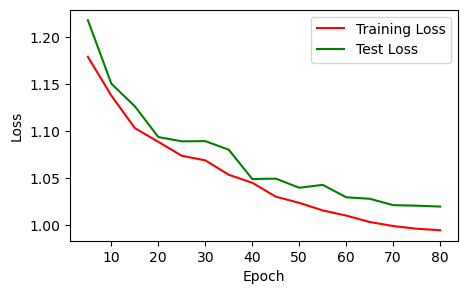

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:10<00:00, 112.85it/s]


About to evaluate dnabert-s__epc_pool__phylophlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/dnabert-s/epc_pool/seed_12345
Target tsv output: results/random_split_1004/dnabert-s__epc_pool__phylophlan__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan/dnabert-s.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 384, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


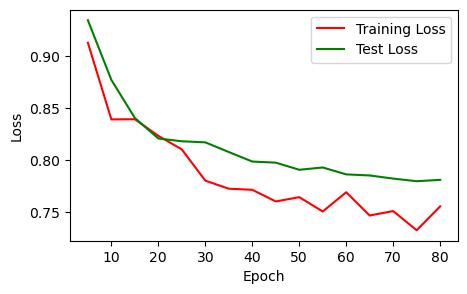

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:35<00:00, 33.87it/s]


About to evaluate dnabert-s__epc_pool__phylophlan [seed=12346]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/dnabert-s/epc_pool/seed_12346
Target tsv output: results/random_split_1004/dnabert-s__epc_pool__phylophlan__12346.tsv
About to evaluate dnabert-s__epc_pool__phylophlan [seed=12347]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/dnabert-s/epc_pool/seed_12347
Target tsv output: results/random_split_1004/dnabert-s__epc_pool__phylophlan__12347.tsv


[ERROR] Model unable to be evaluated. Reason: Pytorch model config '/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/dnabert-s/epc_pool/seed_12346/model_config.json' does not exist!
[ERROR] Model unable to be evaluated. Reason: Pytorch model config '/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/dnabert-s/epc_pool/seed_12347/model_config.json' does not exist!


About to evaluate dnabert-s__epc_pool__phylophlan_metaphlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan_metaphlan/dnabert-s/epc_pool/seed_12345
Target tsv output: results/random_split_1004/dnabert-s__epc_pool__phylophlan_metaphlan__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan_metaphlan/dnabert-s.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 584, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


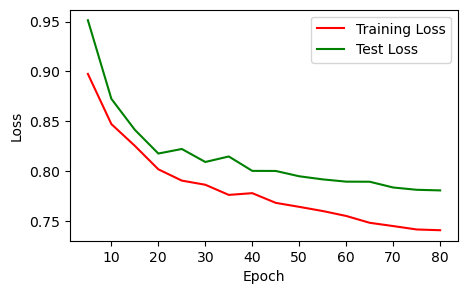

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:54<00:00, 21.91it/s]


About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo-1-8k-base_hyena5/epc_pool/seed_12345
Target tsv output: results/random_split_1004/evo-1-8k-base_hyena5__epc_pool__phylophlan__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan/evo-1-8k-base_hyena5.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 384, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


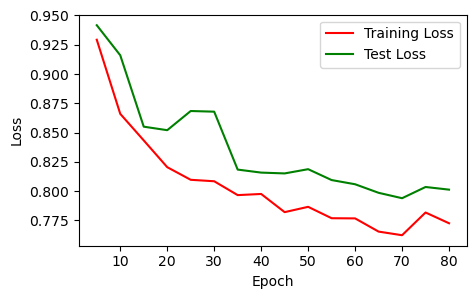

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:40<00:00, 29.66it/s]


About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan [seed=12346]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo-1-8k-base_hyena5/epc_pool/seed_12346
Target tsv output: results/random_split_1004/evo-1-8k-base_hyena5__epc_pool__phylophlan__12346.tsv


[ERROR] Model unable to be evaluated. Reason: Pytorch model config '/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo-1-8k-base_hyena5/epc_pool/seed_12346/model_config.json' does not exist!
[ERROR] Model unable to be evaluated. Reason: Pytorch model config '/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo-1-8k-base_hyena5/epc_pool/seed_12347/model_config.json' does not exist!


About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan [seed=12347]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo-1-8k-base_hyena5/epc_pool/seed_12347
Target tsv output: results/random_split_1004/evo-1-8k-base_hyena5__epc_pool__phylophlan__12347.tsv
About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan_metaphlan/evo-1-8k-base_hyena5/epc_pool/seed_12345
Target tsv output: results/random_split_1004/evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan_metaphlan/evo-1-8k-base_hyena5.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 584, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


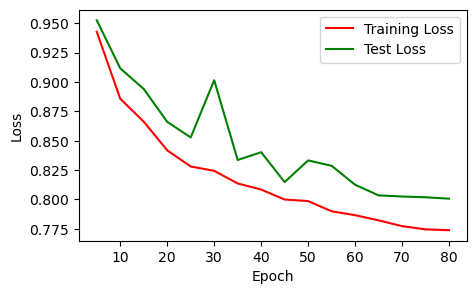

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [01:04<00:00, 18.61it/s]


About to evaluate evo2_7b_hyena10__epc_pool__phylophlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo2_7b_hyena10/epc_pool/seed_12345
Target tsv output: results/random_split_1004/evo2_7b_hyena10__epc_pool__phylophlan__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan/evo2_7b_hyena10.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 384, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


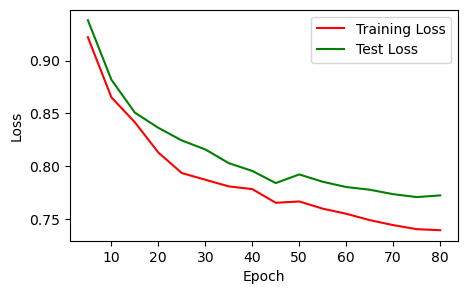

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:39<00:00, 30.29it/s]


About to evaluate evo2_7b_hyena10__epc_pool__phylophlan [seed=12346]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo2_7b_hyena10/epc_pool/seed_12346
Target tsv output: results/random_split_1004/evo2_7b_hyena10__epc_pool__phylophlan__12346.tsv


[ERROR] Model unable to be evaluated. Reason: Pytorch model config '/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo2_7b_hyena10/epc_pool/seed_12346/model_config.json' does not exist!
[ERROR] Model unable to be evaluated. Reason: Pytorch model config '/data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo2_7b_hyena10/epc_pool/seed_12347/model_config.json' does not exist!


About to evaluate evo2_7b_hyena10__epc_pool__phylophlan [seed=12347]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/evo2_7b_hyena10/epc_pool/seed_12347
Target tsv output: results/random_split_1004/evo2_7b_hyena10__epc_pool__phylophlan__12347.tsv
About to evaluate evo2_7b_hyena10__epc_pool__phylophlan_metaphlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan_metaphlan/evo2_7b_hyena10/epc_pool/seed_12345
Target tsv output: results/random_split_1004/evo2_7b_hyena10__epc_pool__phylophlan_metaphlan__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan_metaphlan/evo2_7b_hyena10.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 584, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


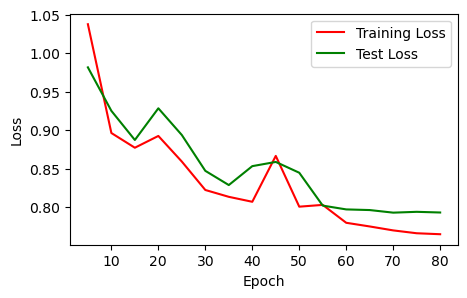

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [01:06<00:00, 18.14it/s]


About to evaluate umap_d100_s1000__set_transformer__offline [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/offline/umap_d100_s1000/set_transformer/seed_12345
Target tsv output: results/random_split_1004/umap_d100_s1000__set_transformer__offline__12345.tsv
HierarchicalSetTransformer config: {'dim_hidden': 56, 'num_inds': 8, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 100}


[ERROR] Model unable to be evaluated. Reason: Model should have num_inds=16. (path = /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/offline/umap_d100_s1000/set_transformer/seed_12345)


About to evaluate dnabert-s__set_transformer__phylophlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/dnabert-s/set_transformer/seed_12345
Target tsv output: results/random_split_1004/dnabert-s__set_transformer__phylophlan__12345.tsv
HierarchicalSetTransformer config: {'dim_hidden': 56, 'num_inds': 8, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 200}


[ERROR] Model unable to be evaluated. Reason: Model should have num_inds=16. (path = /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/random_split_1004/trained_model/phylophlan/dnabert-s/set_transformer/seed_12345)


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:23<00:00, 51.83it/s]


Baseline method: sgb_nearest_neighbor_KNN_30
Target tsv output: results/random_split_1004/sgb_nearest_neighbor_KNN_30.tsv


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:23<00:00, 51.86it/s]


Baseline method: sgb_nearest_neighbor_KNN_40
Target tsv output: results/random_split_1004/sgb_nearest_neighbor_KNN_40.tsv


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:23<00:00, 51.64it/s]


In [22]:
# for split_seed in [1001, 1002, 1003, 1004]:
for split_seed in [1004]:
    analysis_name = f"random_split_{split_seed}"
    print(f"analysis_name: {analysis_name}")
    evaluate_all(analysis_name, Path("results") / analysis_name, overwrite=False)
    # evaluate_ablated(analysis_name, Path("results") / analysis_name, overwrite=False)


# Plotting

## Matplotlib/Seaborn plotting fn

In [23]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, y, sample_col, show_scatter: bool = False, annot_pvals: bool = False, ax=None, hue_order=None, palette=None, correction='fdr_bh', fontsize: int = 12):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    
    if hue_order is None:
        hue_order = sorted(data[hue].unique())
    group_locs = {level: i for i, level in enumerate(hue_order)}
    
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, legend=False, showfliers=False)
    if show_scatter:
        sb.stripplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, alpha=0.2, edgecolor='black', linewidth=1.0)

    ax.set_xticks(list(range(len(hue_order))), hue_order, rotation=90, fontsize=fontsize)

    if annot_pvals:
        # Get y-axis range for proper scaling
        ylim = ax.get_ylim()
        y_range = ylim[1] - ylim[0]
        y_max = data[y].max()
        
        # Starting position for annotations (4% above data max)
        y_start = y_max + y_range * 0.04
        
        # Pairwise significance testing
        pairs = list(itertools.combinations(hue_order, 2))
        p_values = []
        test_results = []
        
        # Collect all p-values first
        for h1, h2 in pairs:
            d1 = data[data[hue] == h1][[sample_col, y]]
            d2 = data[data[hue] == h2][[sample_col, y]]
            joined = d1.merge(d2, on=sample_col, suffixes=('_1', '_2'))
            v1 = joined[y + '_1']
            v2 = joined[y + '_2']
            stat, p = wilcoxon(v1, v2, zero_method='wilcox', correction=False)
            p_values.append(p)
            test_results.append((h1, h2, stat, p))
        
        # Apply multiple hypothesis correction
        if len(p_values) > 1:
            rejected, p_corrected, _, _ = smt.multipletests(p_values, method=correction)
        else:
            rejected = [p_values[0] < 0.05] if p_values else []
            p_corrected = p_values
        
        # Annotation with corrected p-values
        annotation_idx = 0  # Counter for positioning annotations
        for idx, (h1, h2, stat, p_raw) in enumerate(test_results):
            p_adj = p_corrected[idx]
            
            stars = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'n.s.'
            
            x1, x2 = group_locs[h1], group_locs[h2]
            
            # Calculate bracket position and height based on y-axis range
            y_bar = y_start + annotation_idx * y_range * 0.15  # 15% spacing between brackets
            bracket_height = y_range * 0.02  # 2% of y-range for bracket height
            text_offset = y_range * 0.001  # offset for text above bracket
            
            # Draw significance bracket
            ax.plot([x1, x1, x2, x2], 
                    [y_bar, y_bar + bracket_height, y_bar + bracket_height, y_bar], 
                    lw=1.2, c='k')
            
            # Add significance text with adjusted p-value info
            text = f"{stars}"
            ax.text((x1 + x2) / 2, y_bar + bracket_height + text_offset, 
                    text, ha='center', va='bottom', color='k', fontsize=11)
            
            annotation_idx += 1
        
        # Add correction method info to plot
        ax.text(0.02, 0.98, f'Multiple comparisons: {correction}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
    else:
        print("Skipping p-value annotation.")
    
    return ax

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_methods_with_seeds(
    ax,
    data,
    method_order,
    method_colors,
    metric='KL_err',
    deterministic_methods=None,
    show_seed_dots=True,
    seed_summary='median',  # 'median' or 'mean' — how to summarize per-seed
    sample_aggregation='mean',  # 'mean' or 'median' — how to combine seeds per sample
    reference_line='best_baseline',  # 'best_baseline', a numeric value, or None
    dot_size=30,
    dot_jitter=0.08,
    box_width=0.6,
    seed_dot_color=None,  # if None, use a darkened version of method_colors
    rng_seed=0,
):
    """
    Plot a boxplot per method showing test-sample loss distribution, with
    per-seed summary dots overlaid for stochastic (NN) methods.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot into.
    data : pd.DataFrame
        Long-format dataframe with columns including:
        ['SampleId', 'Method', 'Seed', metric, ...]. Deterministic methods
        should still have a 'Seed' column (any constant value is fine — they
        get aggregated to one value per sample regardless).
    method_order : list of str
        Order of methods on the x-axis (left to right).
    method_colors : dict
        Mapping {method_name: color} for box fill and dot color.
    metric : str
        Column name of the loss/score to plot on y-axis.
    deterministic_methods : list of str or None
        Methods that have no meaningful seed variability (baselines).
        These get a boxplot only, no overlaid dots. If None, methods with
        a single unique Seed value are auto-detected as deterministic.
    show_seed_dots : bool
        Whether to overlay per-seed summary dots on stochastic methods.
    seed_summary : {'median', 'mean'}
        Statistic used to summarize each seed's test-set performance (one
        dot per seed).
    sample_aggregation : {'mean', 'median'}
        How to combine multiple seeds into one value per sample, for the
        boxplot. Should match `seed_summary` for consistency.
    reference_line : 'best_baseline', numeric, or None
        Draws a horizontal reference line. 'best_baseline' uses the median
        of the best-performing deterministic method (lowest median loss).
    dot_size : int
        Marker size for per-seed dots.
    dot_jitter : float
        Horizontal jitter for dots (in units of x-axis position).
    box_width : float
        Width of each boxplot.
    seed_dot_color : color or None
        Color of the per-seed dots. If None, uses a darker shade of the
        corresponding method's color.
    rng_seed : int
        Seed for the jitter RNG (so dot positions are reproducible).
    """
    rng = np.random.default_rng(rng_seed)

    # Auto-detect deterministic methods if not provided
    if deterministic_methods is None:
        deterministic_methods = [
            m for m in method_order
            if data.loc[data['Method'] == m, 'Seed'].nunique() <= 1
        ]
    deterministic_set = set(deterministic_methods)

    # --- Per-sample values for the boxplot ---
    # For each (Method, SampleId), aggregate across seeds. For deterministic
    # methods this is a no-op since there's only one seed.
    agg_fn = np.median if sample_aggregation == 'median' else np.mean
    per_sample = (
        data
        .groupby(['Method', 'SampleId'])[metric]
        .agg(agg_fn)
        .reset_index()
    )

    # --- Per-seed summary for the overlaid dots ---
    # For each (Method, Seed), compute summary statistic across the test set.
    seed_fn = np.median if seed_summary == 'median' else np.mean
    per_seed = (
        data
        .groupby(['Method', 'Seed'])[metric]
        .agg(seed_fn)
        .reset_index()
    )

    # --- Draw boxplots ---
    box_data = [
        per_sample.loc[per_sample['Method'] == m, metric].values
        for m in method_order
    ]
    positions = np.arange(len(method_order))

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markersize=2, markerfacecolor='gray',
                        markeredgecolor='none', alpha=0.4),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1),
        boxprops=dict(linewidth=1),
    )

    # Color each box
    for patch, m in zip(bp['boxes'], method_order):
        color = method_colors.get(m, '#999999')
        patch.set_facecolor(color)
        patch.set_alpha(0.9)
        patch.set_edgecolor('black')

    # --- Overlay per-seed dots on stochastic methods ---
    if show_seed_dots:
        for i, m in enumerate(method_order):
            if m in deterministic_set:
                continue
            seed_vals = per_seed.loc[per_seed['Method'] == m, metric].values
            if len(seed_vals) == 0:
                continue
            # Jittered x-positions centered on the boxplot
            x_jitter = rng.uniform(-dot_jitter, dot_jitter, size=len(seed_vals))
            x_pos = np.full(len(seed_vals), i) + x_jitter

            if seed_dot_color is None:
                dot_color = _darken(method_colors.get(m, '#999999'), factor=0.55)
            else:
                dot_color = seed_dot_color

            ax.scatter(
                x_pos, seed_vals,
                s=dot_size,
                color=dot_color,
                edgecolor='white',
                linewidth=0.8,
                zorder=10,  # on top of the boxplot
            )

    # --- Reference line ---
    if reference_line is not None:
        if reference_line == 'best_baseline':
            if deterministic_methods:
                baseline_medians = {
                    m: np.median(per_sample.loc[per_sample['Method'] == m, metric])
                    for m in deterministic_methods
                }
                best_m = min(baseline_medians, key=baseline_medians.get)
                ref_val = baseline_medians[best_m]
                ax.axhline(ref_val, color='gray', linestyle='--', linewidth=1,
                           alpha=0.7, zorder=1)
            # If no deterministic methods, skip silently
        else:
            ax.axhline(float(reference_line), color='gray', linestyle='--',
                       linewidth=1, alpha=0.7, zorder=1)

    # --- Axis cosmetics ---
    ax.set_xticks(positions)
    ax.set_xticklabels(method_order, rotation=30, ha='right')
    ax.set_ylabel(metric)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

    return ax


def _darken(color, factor=0.6):
    """Return a darker version of a color (any matplotlib color spec)."""
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

# Figures for paper

In [25]:
import matplotlib.patches as mpatches
from collections import defaultdict

def render_legend_groups(method_names: List[str], color_dict: Dict[str, np.ndarray], display_names_dict: Dict[str, str], ax, font_size: int):
    def get_group_of(_method): 
        if _method.startswith("sgb_nearest_neighbor") or _method == "uniform":
            return "baseline"
        else:
            return _method.split(":")[0]
            
    # Group handles by prefix before ':'
    groups = defaultdict(list)
    for method_name in method_names:
        group = get_group_of(method_name)
        color = color_dict[method_name]
        groups[group].append(mpatches.Patch(color=color, label=display_names_dict[method_name]))

    columns = list(groups.values())
    n_cols = len(columns)
    n_rows = max(len(col) for col in columns)

    # Pad each column to n_rows with unique blank patches
    group_names = list(groups.keys())
    padded_columns = []
    for group, col in groups.items():
        padded_columns.append(
            col + [mpatches.Patch(visible=False, label="") for _ in range(n_rows - len(col))]
        )
    print("Rendering n_rows = {}, n_cols = {} Legend layout.".format(n_rows, n_cols))

    # Interleave row by row so matplotlib's row-by-row fill puts items in the right column
    interleaved = []
    for col in padded_columns:
        interleaved.extend(col)
        
    ax.legend(
        handles=interleaved,
        ncols=n_cols,
        loc="center",
        frameon=False,
        columnspacing=1.0,
        prop={'family': "Fira Sans", 'weight': 'normal', 'size': font_size}
    )

In [26]:
def extract_concat_result(results_dir: Path, method_names: List[str]):
    eval_result_dfs = []

    # search for all seeded runs
    def is_baseline(name) -> bool:
        if 'uniform' in name or 'nearest_neighbor' in name:
            return True
        else:
            return False

    for method_name in method_names:
        # parse gene set name, if applicable.
        tokens = method_name.split("__")
        if len(tokens) == 3:
            # found torch model.
            prediction_method_name = "__".join(tokens[:2])
            gene_set_name = tokens[2]
        else:
            # found baseline.
            prediction_method_name = method_name
            gene_set_name = 'offline'
        
        if is_baseline(method_name):
            tsv_path = results_dir / f'{method_name}.tsv'
            seed_val = np.nan
            print(tsv_path)
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name,
                    GeneSet=gene_set_name,
                    PredictionMethod=prediction_method_name,
                    Seed=seed_val,
                )
            )
        else:
            for tsv_path in results_dir.glob(f"{method_name}__*.tsv"):
                seed_val = int(tsv_path.stem.split("__")[-1])
                eval_result_dfs.append(
                    pd.read_csv(tsv_path, sep='\t').assign(
                        Method=method_name,
                        GeneSet=gene_set_name,
                        PredictionMethod=prediction_method_name,
                        Seed=seed_val,
                    )
                )
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

results/pcoa_split/uniform.tsv
results/pcoa_split/sgb_nearest_neighbor.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_10.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_20.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_30.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_40.tsv
results/random_split_1001/uniform.tsv
results/random_split_1001/sgb_nearest_neighbor.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_10.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_20.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_30.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_40.tsv
results/random_split_1002/uniform.tsv
results/random_split_1002/sgb_nearest_neighbor.tsv
results/random_split_1002/sgb_nearest_neighbor_KNN_10.tsv
results/random_split_1002/sgb_nearest_neighbor_KNN_20.tsv
results/random_split_1002/sgb_nearest_neighbor_KNN_30.tsv
results/random_split_1002/sgb_nearest_neighbor_KNN_40.tsv
results/random_split_1003/uniform.tsv
results/random_split_1003/sgb_nearest_nei

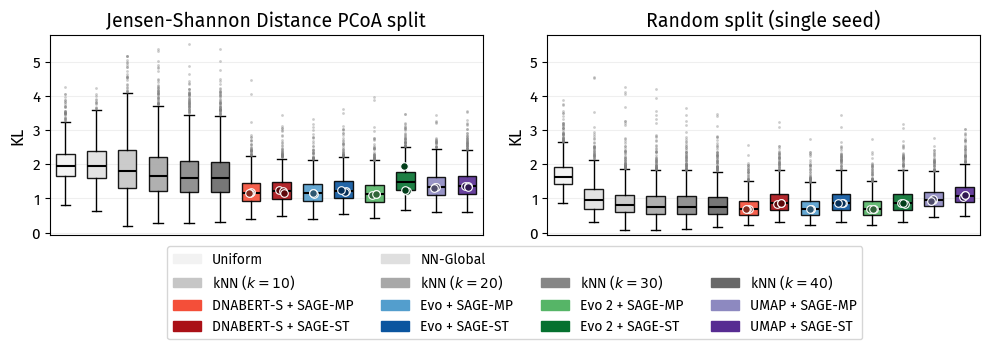

In [28]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from collections import defaultdict
from itertools import zip_longest

# ==================== data
baseline_methods_to_plot = [
    'uniform',
    'sgb_nearest_neighbor',
    'sgb_nearest_neighbor_KNN_10',
    'sgb_nearest_neighbor_KNN_20',
    'sgb_nearest_neighbor_KNN_30',
    'sgb_nearest_neighbor_KNN_40',
]
torch_models_to_plot = [
    'dnabert-s__epc_pool__phylophlan',
    'dnabert-s__set_transformer__phylophlan',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan',
    'evo-1-8k-base_hyena5__set_transformer__phylophlan',
    'evo2_7b_hyena10__epc_pool__phylophlan',
    'evo2_7b_hyena10__set_transformer__phylophlan',
    'umap_d100_s1000__epc_pool__offline',
    'umap_d100_s1000__set_transformer__offline',
]
pcoa_result_df = extract_concat_result(Path('results') / 'pcoa_split', baseline_methods_to_plot + torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / f'random_split_{rng_seed}', baseline_methods_to_plot + torch_models_to_plot)
    for rng_seed in [1001, 1002, 1003, 1004]
    # for rng_seed in [1001]
}


# ==================== plot
width = 12
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 50

fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.15, width_ratios=[1, 1], height_ratios=[1, 0.5])


this_method_order = baseline_methods_to_plot + torch_models_to_plot
print(this_method_order)
baseline_colors = iter(sb.color_palette('Grays', 8))

plot_palette = {
    'uniform': next(baseline_colors),
    'sgb_nearest_neighbor': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_10': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_20': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_30': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_40': next(baseline_colors),
    'dnabert-s__epc_pool__phylophlan': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool__phylophlan': sb.color_palette('Greens', n_colors=6)[3],
    'umap_d100_s1000__epc_pool__offline': sb.color_palette('Purples', n_colors=6)[3],
    'dnabert-s__set_transformer__phylophlan': sb.color_palette('Reds', n_colors=6)[-1],
    'evo-1-8k-base_hyena5__set_transformer__phylophlan': sb.color_palette('Blues', n_colors=6)[-1],
    'evo2_7b_hyena10__set_transformer__phylophlan': sb.color_palette('Greens', n_colors=6)[-1],
    'umap_d100_s1000__set_transformer__offline': sb.color_palette('Purples', n_colors=6)[-1],
}
name_mapping = {
    'uniform': 'Uniform',
    'sgb_nearest_neighbor': 'NN-Global',
    'sgb_nearest_neighbor_KNN_10': r'kNN ($k=10$)',
    'sgb_nearest_neighbor_KNN_20': r'kNN ($k=20$)',
    'sgb_nearest_neighbor_KNN_30': r'kNN ($k=30$)',
    'sgb_nearest_neighbor_KNN_40': r'kNN ($k=40$)',
    
    'dnabert-s__epc_pool__phylophlan': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool__phylophlan': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool__offline': 'UMAP + SAGE-MP',
    
    'dnabert-s__set_transformer__phylophlan': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer__phylophlan': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer__phylophlan': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer__offline': 'UMAP + SAGE-ST',
}

legend_ax = fig.add_subplot(gs[-1, :])
legend_ax.axis("off")
cat1 = ['uniform', 'sgb_nearest_neighbor']
cat2 = ['sgb_nearest_neighbor_KNN_10', 'sgb_nearest_neighbor_KNN_20', 'sgb_nearest_neighbor_KNN_30', 'sgb_nearest_neighbor_KNN_40']
cat3 = ['dnabert-s__epc_pool__phylophlan', 'evo-1-8k-base_hyena5__epc_pool__phylophlan', 'evo2_7b_hyena10__epc_pool__phylophlan', 'umap_d100_s1000__epc_pool__offline']
cat4 = ['dnabert-s__set_transformer__phylophlan', 'evo-1-8k-base_hyena5__set_transformer__phylophlan', 'evo2_7b_hyena10__set_transformer__phylophlan', 'umap_d100_s1000__set_transformer__offline']
columns = [cat1, cat2, cat3, cat4]
blank = mpatches.Patch(alpha=0, label=" ")

handles = [
    mpatches.Patch(color=plot_palette[m], label=name_mapping[m]) if m else blank
    for row in zip_longest(*columns) for m in row
]

legend_ax.legend(handles=handles, loc="center", frameon=True, title="Methods", ncol=4)

ax1 = fig.add_subplot(gs[0, 0])  # Spans rows 0-1, column 0
# ax2 = fig.add_subplot(gs[1, 0])  # Spans rows 0-1, column 1
# boxplot_with_paired_significance(pcoa_result_df.loc[(pcoa_result_df['Method'].isin(this_method_order) & (pcoa_result_df['Seed'] == 12346)) | pcoa_result_df['Method'].isin(baseline_methods_to_plot)], hue='Method', y='KL_err', sample_col='Sample', ax=ax1, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)

plot_methods_with_seeds(
    ax1,
    pcoa_result_df,
    this_method_order,
    plot_palette,
    deterministic_methods=baseline_methods_to_plot,
    show_seed_dots=True,
    seed_summary='median',
    sample_aggregation='mean',
    reference_line=None,
)

ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_xlabel(None)
# ax1.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
ax1.set_xticks([])

# boxplot_with_paired_significance(pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)], hue='Method', y='RMSL_err', sample_col='Sample', ax=ax2, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax2.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.set_xlabel(None)
# # ax2.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
# ax2.set_xticks([])


ax3 = fig.add_subplot(gs[0, 1])  # Spans rows 0-1, column 0
# ax4 = fig.add_subplot(gs[1, 1])  # Spans rows 0-1, column 1
_result_df = rng_result_dfs[1001]
# boxplot_with_paired_significance(_result_df.loc[(_result_df['Method'].isin(this_method_order) & (_result_df['Seed'] == 12346)) | _result_df['Method'].isin(baseline_methods_to_plot)], hue='Method', y='KL_err', sample_col='Sample', ax=ax3, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)

plot_methods_with_seeds(
    ax3,
    _result_df,
    this_method_order,
    plot_palette,
    deterministic_methods=baseline_methods_to_plot,
    show_seed_dots=True,
    seed_summary='median',
    sample_aggregation='mean',
    reference_line=None,
)


ax3.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax3.set_xlabel(None)
# ax3.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax3.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
ax3.set_xticks([])

# boxplot_with_paired_significance(_result_df.loc[_result_df['Method'].isin(this_method_order)], hue='Method', y='RMSL_err', sample_col='Sample', ax=ax4, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax4.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax4.set_xlabel(None)
# # ax4.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
# ax4.set_xticks([])

ax3.sharey(ax1)
# ax4.sharey(ax2)



from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax3]:
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)
    ax.grid(axis="y", linestyle="-", alpha=0.2)


legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")


plt.savefig("results/sgb_pcoa_and_rng_1001_metrics.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/sgb_pcoa_and_rng_1001_metrics.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")

In [29]:
# ==================== render table
this_method_order = baseline_methods_to_plot + torch_models_to_plot
latex_mapping = {
    'uniform': 'Uniform',
    'sgb_nearest_neighbor': 'NN-Global',
    'sgb_nearest_neighbor_KNN_10': r'kNN ($k=10$)',
    'sgb_nearest_neighbor_KNN_20': r'kNN ($k=20$)',
    'sgb_nearest_neighbor_KNN_30': r'kNN ($k=30$)',
    'sgb_nearest_neighbor_KNN_40': r'kNN ($k=40$)',
    
    'dnabert-s__epc_pool__phylophlan': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool__phylophlan': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool__offline': 'UMAP + SAGE-MP',
    
    'dnabert-s__set_transformer__phylophlan': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer__phylophlan': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer__phylophlan': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer__offline': 'UMAP + SAGE-ST',
}


""" Render table """
pcoa_result_df = extract_concat_result(Path('results') / 'pcoa_split', baseline_methods_to_plot + torch_models_to_plot)
_sections = []
for rng_seed, rng_result_df in rng_result_dfs.items():
    section = rng_result_df.copy()
    section['DataSplitSeed'] = rng_seed
    _sections.append(section)
rng_full_df = pd.concat(_sections, ignore_index=True)
del _sections



def compute_mean_std_of_medians(
    df,
    method_order,
    latex_mapping,
    metric='KL_err',
    seed_cols=('Seed',),
):
    """
    For each method:
      - Group by all seed_cols to define "runs" (e.g., one run = one
        (DataSplitSeed, TrainingSeed) combination).
      - For each run, compute median of `metric` across samples.
      - Report mean ± std across the per-run medians.

    Deterministic methods (all NaN seeds, or single unique run) get the
    median across all their samples and std = NaN.
    """
    sub = df.loc[df['Method'].isin(method_order)].copy()
    sub = sub.assign(Method=sub['Method'].map(latex_mapping))

    results = []
    for method, method_df in sub.groupby('Method'):
        # Which seed cols actually vary (not all NaN) for this method?
        active_seed_cols = [
            c for c in seed_cols
            if c in method_df.columns and not method_df[c].isna().all()
        ]

        if not active_seed_cols:
            # No seed structure at all → single deterministic median
            results.append({
                'Method': method,
                'mean': method_df[metric].median(),
                'std': np.nan,
                'n_runs': 1,
            })
            continue

        # Per-run median across samples
        per_run_median = method_df.groupby(list(active_seed_cols))[metric].median()
        n_runs = len(per_run_median)

        if n_runs <= 1:
            results.append({
                'Method': method,
                'mean': per_run_median.iloc[0] if n_runs == 1 else np.nan,
                'std': np.nan,
                'n_runs': n_runs,
            })
        else:
            results.append({
                'Method': method,
                'mean': per_run_median.mean(),
                'std': per_run_median.std(ddof=1),
                'n_runs': n_runs,
            })

    return pd.DataFrame(results).set_index('Method')

# PCoA: only training seed varies (single data split)
pcoa_stats = compute_mean_std_of_medians(
    pcoa_result_df, this_method_order, latex_mapping,
    metric='KL_err', seed_cols=('Seed',),
)

# Random: both data split seed AND training seed vary
rng_stats = compute_mean_std_of_medians(
    rng_full_df, this_method_order, latex_mapping,
    metric='KL_err', seed_cols=('DataSplitSeed', 'Seed'),
)

print("PCoA stats:")
print(pcoa_stats)
print()
print("Random stats:")
print(rng_stats)



import numpy as np
import pandas as pd


def compute_variance_decomposition(
    df, method_order, latex_mapping,
    metric='KL_err',
    split_col='DataSplitSeed',
    seed_col='Seed',
):
    """
    For each method, compute:
      - mean: pooled mean across all (split, seed) runs
      - std_seed: training-seed variability (within-split std, averaged across splits)
      - std_split: split-to-split variability (std of per-split means)
      - n_runs: total (split, seed) combinations

    Handles four cases:
      1. Multi-split, multi-seed (NN methods on Random): full decomposition
      2. Single-split, multi-seed (NN methods on PCoA): std_seed only
      3. Multi-split, no-seed (deterministic baselines on Random): std_split only
      4. Single-split, no-seed (deterministic baselines on PCoA): single value
    """
    sub = df.loc[df['Method'].isin(method_order)].copy()
    sub = sub.assign(Method=sub['Method'].map(latex_mapping))

    has_split = split_col in sub.columns and not sub[split_col].isna().all()
    has_seed = seed_col in sub.columns and not sub[seed_col].isna().all()

    results = []
    for method, method_df in sub.groupby('Method'):
        method_has_seed = (
            has_seed and not method_df[seed_col].isna().all()
            and method_df[seed_col].nunique() > 1
        )
        method_has_split = (
            has_split and not method_df[split_col].isna().all()
            and method_df[split_col].nunique() > 1
        )

        # Determine grouping for per-run aggregation
        group_cols = []
        if has_split and not method_df[split_col].isna().all():
            group_cols.append(split_col)
        if has_seed and not method_df[seed_col].isna().all():
            group_cols.append(seed_col)

        if group_cols:
            per_run = method_df.groupby(group_cols)[metric].median().reset_index()
        else:
            per_run = pd.DataFrame({metric: [method_df[metric].median()]})

        n_runs = len(per_run)
        overall_mean = per_run[metric].mean()

        # std_seed: within-split std across training seeds
        if method_has_seed and method_has_split:
            # Multi-split, multi-seed: avg of within-split stds
            within_split_stds = (
                per_run.groupby(split_col)[metric].std(ddof=1).dropna()
            )
            std_seed = within_split_stds.mean() if len(within_split_stds) > 0 else np.nan
        elif method_has_seed and not method_has_split:
            # Single-split, multi-seed: just the std across seeds
            std_seed = per_run[metric].std(ddof=1)
        else:
            std_seed = np.nan

        # std_split: between-split std of per-split means
        if method_has_split and method_has_seed:
            per_split_means = per_run.groupby(split_col)[metric].mean()
            std_split = per_split_means.std(ddof=1)
        elif method_has_split and not method_has_seed:
            # Multi-split, no seed: just std across splits
            std_split = per_run[metric].std(ddof=1)
        else:
            std_split = np.nan

        results.append({
            'Method': method,
            'mean': overall_mean,
            'std_seed': std_seed,
            'std_split': std_split,
            'n_runs': n_runs,
        })

    return pd.DataFrame(results).set_index('Method')


def fmt_decomposed_cell(mean, std_seed, std_split, is_best):
    """
    Format a cell as 'mean ± std_seed (seed) ± std_split (split)', omitting
    components that don't apply. Bolded if is_best.
    """
    if pd.isna(mean):
        return '--'

    has_seed = not pd.isna(std_seed)
    has_split = not pd.isna(std_split)

    parts = [f'{mean:.4f}']
    if has_seed:
        parts.append(rf'$\pm$ {std_seed:.4f} (seed)')
    if has_split:
        parts.append(rf'$\pm$ {std_split:.4f} (split)')

    cell = ' '.join(parts)

    if is_best:
        return rf'\textbf{{{cell}}}'
    return cell


# --- Apply to both splits ---
this_method_order_mapped = [
    latex_mapping[m] for m in this_method_order if m in latex_mapping
]

pcoa_stats = compute_variance_decomposition(
    pcoa_result_df, this_method_order, latex_mapping,
    metric='KL_err',
    split_col='DataSplitSeed',  # may not exist; function handles gracefully
    seed_col='Seed',
)

rng_stats = compute_variance_decomposition(
    rng_full_df, this_method_order, latex_mapping,
    metric='KL_err',
    split_col='DataSplitSeed',
    seed_col='Seed',
)

display_df = pcoa_stats.merge(
    rng_stats,
    left_index=True, right_index=True,
    how='outer',
    suffixes=['_pcoa', '_rng'],
).reindex(this_method_order_mapped)

min_pcoa_mean = display_df['mean_pcoa'].min()
min_rng_mean = display_df['mean_rng'].min()

display_df['JS-Maximizing Split (KL)'] = display_df.apply(
    lambda r: fmt_decomposed_cell(
        r['mean_pcoa'], r['std_seed_pcoa'], r['std_split_pcoa'],
        r['mean_pcoa'] == min_pcoa_mean,
    ),
    axis=1,
)
display_df['Random Split (KL)'] = display_df.apply(
    lambda r: fmt_decomposed_cell(
        r['mean_rng'], r['std_seed_rng'], r['std_split_rng'],
        r['mean_rng'] == min_rng_mean,
    ),
    axis=1,
)

display(display_df[[
    'mean_pcoa', 'std_seed_pcoa', 'std_split_pcoa',
    'mean_rng', 'std_seed_rng', 'std_split_rng',
    'JS-Maximizing Split (KL)', 'Random Split (KL)',
]])

# --- LaTeX output ---
latex = display_df[['JS-Maximizing Split (KL)', 'Random Split (KL)']].to_latex(
    index=True,
    escape=False,
    column_format="lcc",
    caption=(
        "Test set KL divergence on the two splits. Each cell reports "
        r"$\mu \pm \sigma_\mathrm{seed}~(\text{seed}) \pm \sigma_\mathrm{split}~(\text{split})$, "
        r"where $\mu$ is the pooled mean across (data split, training seed) "
        r"combinations of the per-run median test KL, "
        r"$\sigma_\mathrm{seed}$ is the within-split training-seed std "
        r"(averaged across splits), and $\sigma_\mathrm{split}$ is the "
        r"between-split std of per-split means. Components that don't apply "
        r"are omitted: the JS-Maximizing column has no $\sigma_\mathrm{split}$ "
        r"(single split), and deterministic baselines have no $\sigma_\mathrm{seed}$. "
        r"The minimal mean in each column is bolded."
    ),
    label="table:benchmark_asv",
    position="ht",
)

# Booktabs midrules between rows
lines = latex.splitlines()
result = []
for line in lines:
    result.append(line)
    if line.strip().endswith(r"\\") and not any(
        marker in line for marker in [r"\toprule", r"\midrule", r"\bottomrule"]
    ):
        result.append(r"\midrule")
latex = "\n".join(result)
print(latex)

results/pcoa_split/uniform.tsv
results/pcoa_split/sgb_nearest_neighbor.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_10.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_20.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_30.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_40.tsv
PCoA stats:
                         mean       std  n_runs
Method                                         
DNABERT-S + SAGE-MP  1.168642  0.025748       3
DNABERT-S + SAGE-ST  1.207113  0.042935       3
Evo + SAGE-MP        1.143861  0.016012       3
Evo + SAGE-ST        1.222974  0.019860       3
Evo 2 + SAGE-MP      1.119160  0.008806       3
Evo 2 + SAGE-ST      1.467807  0.423465       3
NN-Global            1.961392       NaN       1
UMAP + SAGE-MP       1.324403  0.017215       3
UMAP + SAGE-ST       1.362971  0.015152       3
Uniform              1.956493       NaN       1
kNN ($k=10$)         1.800566       NaN       1
kNN ($k=20$)         1.657699       NaN       1
kNN ($k=30$)         1.598742       N

,mean_pcoa,std_seed_pcoa,std_split_pcoa,mean_rng,std_seed_rng,std_split_rng,JS-Maximizing Split (KL),Random Split (KL)
Method,,,,,,,,
Uniform,1.956493,NaN,NaN,1.620392,NaN,0.004940,1.9565,1.6204 $\pm$ 0.0049 (split)
NN-Global,1.961392,NaN,NaN,0.960229,NaN,0.012884,1.9614,0.9602 $\pm$ 0.0129 (split)
kNN ($k=10$),1.800566,NaN,NaN,0.816894,NaN,0.021454,1.8006,0.8169 $\pm$ 0.0215 (split)
kNN ($k=20$),1.657699,NaN,NaN,0.781460,NaN,0.023679,1.6577,0.7815 $\pm$ 0.0237 (split)
kNN ($k=30$),1.598742,NaN,NaN,0.772951,NaN,0.016019,1.5987,0.7730 $\pm$ 0.0160 (split)
kNN ($k=40$),1.591657,NaN,NaN,0.767044,NaN,0.013500,1.5917,0.7670 $\pm$ 0.0135 (split)
DNABERT-S + SAGE-MP,1.168642,0.025748,NaN,0.693001,0.008815,0.010360,1.1686 $\pm$ 0.0257 (seed),\textbf{0.6930 $\pm$ 0.0088 (seed) $\pm$ 0.010...
DNABERT-S + SAGE-ST,1.207113,0.042935,NaN,0.860627,0.002109,0.009421,1.2071 $\pm$ 0.0429 (seed),0.8606 $\pm$ 0.0021 (seed) $\pm$ 0.0094 (split)
Evo + SAGE-MP,1.143861,0.016012,NaN,0.700477,0.018932,0.011309,1.1439 $\pm$ 0.0160 (seed),0.7005 $\pm$ 0.0189 (seed) $\pm$ 0.0113 (split)


\begin{table}[ht]
\caption{Test set KL divergence on the two splits. Each cell reports $\mu \pm \sigma_\mathrm{seed}~(\text{seed}) \pm \sigma_\mathrm{split}~(\text{split})$, where $\mu$ is the pooled mean across (data split, training seed) combinations of the per-run median test KL, $\sigma_\mathrm{seed}$ is the within-split training-seed std (averaged across splits), and $\sigma_\mathrm{split}$ is the between-split std of per-split means. Components that don't apply are omitted: the JS-Maximizing column has no $\sigma_\mathrm{split}$ (single split), and deterministic baselines have no $\sigma_\mathrm{seed}$. The minimal mean in each column is bolded.}
\label{table:benchmark_asv}
\begin{tabular}{lcc}
\toprule
 & JS-Maximizing Split (KL) & Random Split (KL) \\
\midrule
Method &  &  \\
\midrule
\midrule
Uniform & 1.9565 & 1.6204 $\pm$ 0.0049 (split) \\
\midrule
NN-Global & 1.9614 & 0.9602 $\pm$ 0.0129 (split) \\
\midrule
kNN ($k=10$) & 1.8006 & 0.8169 $\pm$ 0.0215 (split) \\
\midrule
kNN

In [30]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd


# ==================== Statistical Testing
def get_paired_kl(result_df, method_a, method_b, key_cols, aggregator='mean'):
    """
    Extract paired KL values aligned by `key_cols` for two methods.
    
    Within each (method, key) group, KL is aggregated across any non-key
    dimensions (typically training seeds) using `aggregator` ('mean' or
    'median'). This gives one value per (method, key), then paired across
    methods.
    """
    agg_fn = np.mean if aggregator == 'mean' else np.median

    def aggregate(method):
        return (
            result_df.loc[result_df['Method'] == method]
                     .groupby(list(key_cols))['KL_err']
                     .agg(agg_fn)
                     .reset_index()
        )

    df_a = aggregate(method_a)
    df_b = aggregate(method_b)
    merged = df_a.merge(df_b, on=list(key_cols), suffixes=('_a', '_b'))
    return merged['KL_err_a'].values, merged['KL_err_b'].values


def run_pairwise_wilcoxon(result_df, method_order, latex_mapping, key_cols,
                          aggregator='mean'):
    """
    Pairwise Wilcoxon signed-rank tests between all methods in method_order.
    KL values are aggregated across training seeds within each (method, key)
    group before pairing. p-values are BH-corrected.
    """
    display_names = [latex_mapping[m] for m in method_order if m in latex_mapping]
    n = len(display_names)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    pvals_raw = []
    n_paired = []
    for i, j in pairs:
        a, b = get_paired_kl(
            result_df, method_order[i], method_order[j], key_cols, aggregator,
        )
        n_paired.append(len(a))
        if len(a) < 2:
            pvals_raw.append(np.nan)
            continue
        if np.all(a == b):
            pvals_raw.append(1.0)
            continue
        _, p = stats.wilcoxon(a, b, alternative='two-sided')
        pvals_raw.append(p)

    # BH correction, skipping NaN entries
    pvals_arr = np.array(pvals_raw)
    valid = ~np.isnan(pvals_arr)
    pvals_corrected = np.full_like(pvals_arr, np.nan)
    if valid.any():
        _, pc, _, _ = multipletests(pvals_arr[valid], method='fdr_bh')
        pvals_corrected[valid] = pc

    pval_df = pd.DataFrame(np.nan, index=display_names, columns=display_names)
    for (i, j), p in zip(pairs, pvals_corrected):
        pval_df.iloc[i, j] = p
        pval_df.iloc[j, i] = p

    print(f"  Paired observations per test: "
          f"min={min(n_paired)}, max={max(n_paired)}, "
          f"median={int(np.median(n_paired))}")

    return pval_df


# JS-maximizing split: pair by SampleId, average across training seeds
print("=== PCoA p-value matrix ===")
pval_matrix_pcoa = run_pairwise_wilcoxon(
    pcoa_result_df, this_method_order, latex_mapping,
    key_cols=['SampleId'],
    aggregator='mean',
)

# Random split: pair by (DataSplitSeed, SampleId), average across training seeds
print("=== Random split p-value matrix ===")
pval_matrix_rng = run_pairwise_wilcoxon(
    rng_full_df, this_method_order, latex_mapping,
    key_cols=['DataSplitSeed', 'SampleId'],
    aggregator='mean',
)


# ==================== Render as LaTeX 2D grids
def pval_to_latex_cell(p, threshold=0.05):
    if np.isnan(p):
        return r'--'
    elif p < threshold:
        return rf'\textbf{{{p:.3f}}}$^*$'
    else:
        return rf'{{\color{{gray}}{p:.3f}}}'


def render_pval_table(pval_df, caption, label):
    methods = pval_df.index.tolist()
    n = len(methods)
    col_format = 'l' + 'c' * n
    header = ' & '.join([''] + methods) + r' \\'
    rows = []
    for i in range(n):
        cells = [methods[i]]
        for j in range(n):
            if i == j:
                cells.append(r'--')
            else:
                cells.append(pval_to_latex_cell(pval_df.iloc[i, j]))
        rows.append(' & '.join(cells) + r' \\')
    grid_table = '\n'.join([
        rf'\begin{{table}}[ht]',
        r'\centering',
        r'\resizebox{\textwidth}{!}{',
        rf'\begin{{tabular}}{{{col_format}}}',
        r'\toprule',
        header,
        r'\midrule',
        '\n'.join(rows),
        r'\bottomrule',
        r'\end{tabular}',
        r'}',
        r'\vspace{4pt}',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        r'\end{table}',
    ])
    return grid_table


grid_pcoa = render_pval_table(
    pval_matrix_pcoa,
    caption=(
        r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample '
        r'KL, JS-maximizing split. Each sample\'s KL is averaged across '
        r'training seeds before pairing. Bold$^*$: $p < 0.05$.'
    ),
    label='table:pval_pcoa',
)

grid_rng = render_pval_table(
    pval_matrix_rng,
    caption=(
        r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample '
        r'KL, random split. Pairing unit is (data split, sample); each '
        r'(split, sample) KL is averaged across training seeds before pairing. '
        r'Bold$^*$: $p < 0.05$.'
    ),
    label='table:pval_rng',
)

print("% ===== Random Split p-value grid =====")
print(grid_rng)
print()
print("% ===== JS-Maximizing Split p-value grid =====")
print(grid_pcoa)

=== PCoA p-value matrix ===
  Paired observations per test: min=1203, max=1203, median=1203
=== Random split p-value matrix ===
  Paired observations per test: min=1203, max=4812, median=3609
% ===== Random Split p-value grid =====
\begin{table}[ht]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccccccccccccc}
\toprule
 & Uniform & NN-Global & kNN ($k=10$) & kNN ($k=20$) & kNN ($k=30$) & kNN ($k=40$) & DNABERT-S + SAGE-MP & DNABERT-S + SAGE-ST & Evo + SAGE-MP & Evo + SAGE-ST & Evo 2 + SAGE-MP & Evo 2 + SAGE-ST & UMAP + SAGE-MP & UMAP + SAGE-ST \\
\midrule
Uniform & -- & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ \\
NN-Global & \textbf{0.000}$^*$ & -- & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$

In [64]:
# from scipy import stats
# from statsmodels.stats.multitest import multipletests
# import numpy as np

# # ==================== Statistical Testing

# def get_paired_kl(result_df, method_a, method_b):
#     """Extract paired KL values aligned by SampleId for two methods."""
#     df_a = result_df.loc[result_df['Method'] == method_a, ['SampleId', 'KL_err']]
#     df_b = result_df.loc[result_df['Method'] == method_b, ['SampleId', 'KL_err']]
#     merged = df_a.merge(df_b, on='SampleId', suffixes=('_a', '_b'))
#     return merged['KL_err_a'].values, merged['KL_err_b'].values

# def run_pairwise_wilcoxon(result_df, method_order, latex_mapping):
#     display_names = [latex_mapping[m] for m in method_order if m in latex_mapping]
#     n = len(display_names)
#     pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

#     pvals_raw = []
#     for i, j in pairs:
#         m_a = method_order[i]
#         m_b = method_order[j]
#         a, b = get_paired_kl(result_df, m_a, m_b)
#         _, p = stats.wilcoxon(a, b, alternative='two-sided')
#         pvals_raw.append(p)

#     _, pvals_corrected, _, _ = multipletests(pvals_raw, method='fdr_bh')

#     pval_df = pd.DataFrame(np.nan, index=display_names, columns=display_names)
#     for (i, j), p in zip(pairs, pvals_corrected):
#         pval_df.iloc[i, j] = p
#         pval_df.iloc[j, i] = p

#     return pval_df

# # JS-maximizing split: full sample-level KL
# pval_matrix_pcoa = run_pairwise_wilcoxon(pcoa_result_df, this_method_order, latex_mapping)

# # Random split: use first seed only
# first_seed = list(rng_result_dfs.keys())[0]
# pval_matrix_rng = run_pairwise_wilcoxon(rng_result_dfs[first_seed], this_method_order, latex_mapping)

# # ==================== Render as LaTeX 2D grids

# def pval_to_latex_cell(p, threshold=0.05):
#     if np.isnan(p):
#         return r'--'
#     elif p < threshold:
#         return rf'\textbf{{{p:.3f}}}$^*$'
#     else:
#         return rf'{{\color{{gray}}{p:.3f}}}'

# def render_pval_table(pval_df, caption, label):
#     methods = pval_df.index.tolist()
#     n = len(methods)

#     col_format = 'l' + 'c' * n
#     header = ' & '.join([''] + methods) + r' \\'

#     rows = []
#     for i in range(n):
#         cells = [methods[i]]
#         for j in range(n):
#             if i == j:
#                 cells.append(r'--')
#             else:
#                 cells.append(pval_to_latex_cell(pval_df.iloc[i, j]))
#         rows.append(' & '.join(cells) + r' \\')

#     grid_table = '\n'.join([
#         rf'\begin{{table}}[ht]',
#         r'\centering',
#         r'\resizebox{\textwidth}{!}{',
#         rf'\begin{{tabular}}{{{col_format}}}',
#         r'\toprule',
#         header,
#         r'\midrule',
#         '\n'.join(rows),
#         r'\bottomrule',
#         r'\end{tabular}',
#         r'}',
#         r'\vspace{4pt}',
#         rf'\caption{{{caption}}}',
#         rf'\label{{{label}}}',
#         r'\end{table}',
#     ])

#     return grid_table

# grid_rng = render_pval_table(
#     pval_matrix_rng,
#     caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, random split (single seed). Bold$^*$: $p < 0.05$.',
#     label='table:pval_rng'
# )

# grid_pcoa = render_pval_table(
#     pval_matrix_pcoa,
#     caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, JS-maximizing split. Bold$^*$: $p < 0.05$.',
#     label='table:pval_pcoa'
# )

# print("% ===== Random Split p-value grid =====")
# print(grid_rng)
# print()
# print("% ===== JS-Maximizing Split p-value grid =====")
# print(grid_pcoa)

## Extra figure showing alternative gene sets

TODO 2026-May-29:
Edit the following code to utilize the training seeds.

In [34]:
torch_models_to_plot = [
    'dnabert-s__epc_pool__phylophlan',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan',
    'evo2_7b_hyena10__epc_pool__phylophlan',
    'dnabert-s__epc_pool__phylophlan_metaphlan',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan',
    'evo2_7b_hyena10__epc_pool__phylophlan_metaphlan',
]


# pcoa_result_df = extract_concat_result(Path('results') / 'pcoa_split', torch_models_to_plot)
# rng_result_dfs = {
#     rng_seed: extract_concat_result(Path('results') / f'random_split_{rng_seed}', torch_models_to_plot)
#     for rng_seed in [1001]
# }

plot_palette = {
    'dnabert-s__epc_pool__phylophlan': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool__phylophlan': sb.color_palette('Greens', n_colors=6)[3],
    'dnabert-s__epc_pool__phylophlan_metaphlan': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool__phylophlan_metaphlan': sb.color_palette('Greens', n_colors=6)[3],
}


""" Render table """
if not Path("results").exists():
    raise Exception("RESULTS dir does not exist!")
    
pcoa_result_df = extract_concat_result(Path('results') / 'pcoa_split', torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / f'random_split_{rng_seed}', torch_models_to_plot)
    for rng_seed in [1001]
}

_sections = []
for rng_seed, rng_result_df in rng_result_dfs.items():
    section = rng_result_df.copy()
    section['DataSplitSeed'] = rng_seed
    _sections.append(section)
rng_full_df = pd.concat(_sections, ignore_index=True)
del _sections

Exception: RESULTS dir does not exist!

Active seed columns: ['Seed']
  Seed: 3 unique values -> [12345, 12346, 12347]
['dnabert-s__epc_pool', 'evo-1-8k-base_hyena5__epc_pool', 'evo2_7b_hyena10__epc_pool']


FileNotFoundError: [Errno 2] No such file or directory: 'results/sgb_extended_gene_set.pdf'

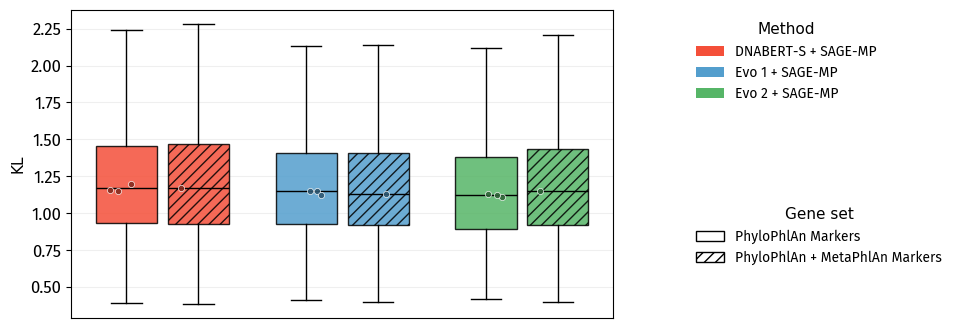

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sb
import numpy as np
from matplotlib.font_manager import FontProperties

METHOD_COLORS = {
    'dnabert-s__epc_pool': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool': sb.color_palette('Greens', n_colors=6)[3],
}

METHOD_NAMES = {
    "dnabert-s__epc_pool": "DNABERT-S + SAGE-MP",
    "evo-1-8k-base_hyena5__epc_pool": "Evo 1 + SAGE-MP",
    "evo2_7b_hyena10__epc_pool": "Evo 2 + SAGE-MP",
}

GENESET_DISPLAY_NAMES = {
    "phylophlan":            "PhyloPhlAn Markers",
    "phylophlan_metaphlan":  "PhyloPhlAn + MetaPhlAn Markers",
}

HATCH_PATTERNS = {
    "phylophlan":            "",
    "phylophlan_metaphlan":  "///",
}

# ============== seed/aggregation setup ==============
SEED_COLS = ('Seed',)             # change to ('DataSplitSeed', 'Seed') for random split
SAMPLE_COL = 'SampleId'
Y_COL = 'KL_err'
DOT_SIZE = 20
DOT_ALPHA = 0.9
DOT_EDGE = 'white'
DOT_EDGE_WIDTH = 0.5
DOT_DARKEN = 0.55

active_seed_cols = [
    c for c in SEED_COLS
    if c in pcoa_result_df.columns and not pcoa_result_df[c].isna().all()
]

print(f"Active seed columns: {active_seed_cols}")
for c in active_seed_cols:
    n_unique = pcoa_result_df[c].nunique()
    unique_vals = sorted(pcoa_result_df[c].dropna().unique().tolist())
    print(f"  {c}: {n_unique} unique values -> {unique_vals}")

# Box data: average training seeds within each (split, sample, method, geneset)
box_group_cols = [c for c in active_seed_cols if c != 'Seed']
box_group_cols = box_group_cols + ['PredictionMethod', 'GeneSet', SAMPLE_COL]
box_data = (
    pcoa_result_df.groupby(box_group_cols)[Y_COL]
                  .mean()
                  .reset_index()
)

# Dot data: per-run median across samples
per_run_median = None
if active_seed_cols:
    dot_group_cols = active_seed_cols + ['PredictionMethod', 'GeneSet']
    per_run_median = (
        pcoa_result_df.groupby(dot_group_cols)[Y_COL]
                      .median()
                      .reset_index()
    )

# ============== plotting ==============
methods = sorted(pcoa_result_df["PredictionMethod"].unique())
print(methods)
genesets = sorted(pcoa_result_df["GeneSet"].unique())

n_methods = len(methods)
n_genesets = len(genesets)

group_width = 0.8
box_width = group_width / n_genesets
offsets = np.linspace(
    -group_width / 2 + box_width / 2,
     group_width / 2 - box_width / 2,
    n_genesets,
)

width = 10
height = 4
fig, axes = plt.subplots(1, 2, figsize=(width, height), width_ratios=[1, 0.3])
plot_ax = axes[0]
legend_ax = axes[1]

rng = np.random.default_rng(0)

for i, method in enumerate(methods):
    color = METHOD_COLORS.get(method, "#888780")
    dot_color = tuple(float(c) * DOT_DARKEN for c in color[:3])

    for j, geneset in enumerate(genesets):
        # --- Boxplot ---
        box_subset = box_data[
            (box_data["PredictionMethod"] == method)
            & (box_data["GeneSet"] == geneset)
        ][Y_COL]

        if box_subset.empty:
            continue

        pos = i + offsets[j]
        hatch = HATCH_PATTERNS.get(geneset, "")

        bp = plot_ax.boxplot(
            box_subset,
            positions=[pos],
            widths=box_width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            medianprops=dict(color="black", linewidth=1),
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.85)
            patch.set_hatch(hatch)

        # --- Per-seed dots ---
        if per_run_median is not None:
            dot_vals = per_run_median[
                (per_run_median["PredictionMethod"] == method)
                & (per_run_median["GeneSet"] == geneset)
            ][Y_COL].values

            if len(dot_vals) > 0:
                jitter = rng.uniform(
                    -box_width * 0.25,
                     box_width * 0.25,
                    size=len(dot_vals),
                )
                x_pos = np.full(len(dot_vals), pos) + jitter

                plot_ax.scatter(
                    x_pos, dot_vals,
                    s=DOT_SIZE,
                    color=dot_color,
                    edgecolor=DOT_EDGE,
                    linewidth=DOT_EDGE_WIDTH,
                    alpha=DOT_ALPHA,
                    zorder=10,
                )

plot_ax.set_xticks([])
plot_ax.set_ylabel("KL", fontsize=11)

# --- Legends ---
method_handles = [
    mpatches.Patch(facecolor=METHOD_COLORS.get(m, "#888780"), label=METHOD_NAMES[m])
    for m in methods
]

geneset_handles = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=HATCH_PATTERNS.get(g, ""),
        label=GENESET_DISPLAY_NAMES[g],
    )
    for g in genesets
]

legend_ax.set_axis_off()
leg1 = legend_ax.legend(
    handles=method_handles, title="Method",
    loc="upper left", bbox_to_anchor=(0, 1),
    prop={'family': 'Fira Sans', 'weight': 'normal'},
    fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE + 1, frameon=False,
)
legend_ax.add_artist(leg1)
legend_ax.legend(
    handles=geneset_handles, title="Gene set",
    loc="upper left", bbox_to_anchor=(0, 0.4),
    prop={'family': 'Fira Sans', 'weight': 'normal'},
    fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE + 1, frameon=False,
)

plot_ax.grid(axis="y", linestyle="-", alpha=0.2)

custom_font = FontProperties(family='Fira Sans', weight='normal', size=FONT_SIZE)
for ax in [plot_ax, legend_ax]:
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)
    ax.grid(axis="y", linestyle="-", alpha=0.2)

plt.savefig("results/sgb_extended_gene_set.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/sgb_extended_gene_set.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")

['dnabert-s__epc_pool', 'evo-1-8k-base_hyena5__epc_pool', 'evo2_7b_hyena10__epc_pool']
done


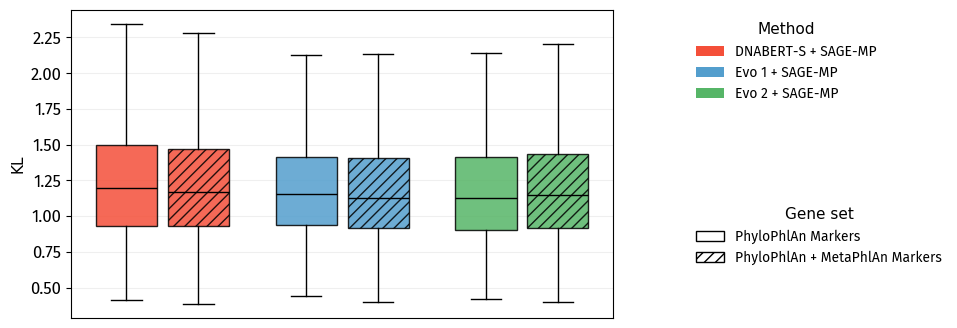

In [53]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import numpy as np

# METHOD_COLORS = {
#     'dnabert-s__epc_pool': sb.color_palette('Reds', n_colors=6)[3],
#     'evo-1-8k-base_hyena5__epc_pool': sb.color_palette('Blues', n_colors=6)[3],
#     'evo2_7b_hyena10__epc_pool': sb.color_palette('Greens', n_colors=6)[3],
# }

# METHOD_NAMES = {
#     "dnabert-s__epc_pool": "DNABERT-S + SAGE-MP",
#     "evo-1-8k-base_hyena5__epc_pool": "Evo 1 + SAGE-MP",
#     "evo2_7b_hyena10__epc_pool": "Evo 2 + SAGE-MP",
# }

# GENESET_DISPLAY_NAMES = {
#     "phylophlan":            "PhyloPhlAn Markers",
#     "phylophlan_metaphlan":  "PhyloPhlAn + MetaPhlAn Markers",
# }

# HATCH_PATTERNS = {
#     "phylophlan":            "",
#     "phylophlan_metaphlan":  "///",
# }

# methods   = sorted(pcoa_result_df["PredictionMethod"].unique())
# print(methods)
# genesets  = sorted(pcoa_result_df["GeneSet"].unique())

# n_methods  = len(methods)
# n_genesets = len(genesets)

# group_width  = 0.8
# box_width    = group_width / n_genesets
# offsets      = np.linspace(
#     -group_width / 2 + box_width / 2,
#      group_width / 2 - box_width / 2,
#     n_genesets
# )

# width = 10
# height = 4
# fig, axes = plt.subplots(1, 2, figsize=(width, height), width_ratios=[1, 0.3])
# plot_ax = axes[0]
# legend_ax = axes[1]

# for i, method in enumerate(methods):
#     color = METHOD_COLORS.get(method, "#888780")
#     for j, geneset in enumerate(genesets):
#         subset = pcoa_result_df[(pcoa_result_df["PredictionMethod"] == method) & (pcoa_result_df["GeneSet"] == geneset)]["KL_err"]
#         if subset.empty:
#             continue

#         pos    = i + offsets[j]
#         hatch  = HATCH_PATTERNS.get(geneset, "")

#         bp = plot_ax.boxplot(
#             subset,
#             positions=[pos],
#             widths=box_width * 0.85,
#             patch_artist=True,
#             manage_ticks=False,
#             showfliers=False,
#             # flierprops=dict(marker="o", markersize=3,
#             #                 markerfacecolor=color, markeredgecolor=color,
#             #                 alpha=0.5),
#             medianprops=dict(color="black", linewidth=1),
#             # whiskerprops=dict(color=color, linewidth=1),
#             # capprops=dict(color=color, linewidth=1),
#             # boxprops=dict(linewidth=1),
#         )

#         for patch in bp["boxes"]:
#             patch.set_facecolor(color)
#             patch.set_alpha(0.85)
#             patch.set_hatch(hatch)
#             # patch.set_edgecolor(color)

# plot_ax.set_xticks([])
# # plot_ax.set_xticklabels([METHOD_NAMES[m] for m in methods], rotation=0, ha="center", fontsize=10)
# plot_ax.set_ylabel("KL", fontsize=11)
# # plot_ax.set_xlabel("Method", fontsize=11)

# # Legend for methods (color)
# method_handles = [
#     mpatches.Patch(facecolor=METHOD_COLORS.get(m, "#888780"), label=METHOD_NAMES[m])
#     for m in methods
# ]

# # Legend for gene sets (hatch)
# geneset_handles = [
#     mpatches.Patch(
#         facecolor="white",
#         edgecolor="black",
#         hatch=HATCH_PATTERNS.get(g, ""),
#         label=GENESET_DISPLAY_NAMES[g]
#     )
#     for g in genesets
# ]

# legend_ax.set_axis_off()
# leg1 = legend_ax.legend(handles=method_handles,  title="Method",
#                  loc="upper left", bbox_to_anchor=(0, 1),
#                  prop={'family': 'Fira Sans', 'weight': 'normal'},
#                  fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE+1, frameon=False)
# legend_ax.add_artist(leg1)
# legend_ax.legend(
#     handles=geneset_handles, title="Gene set",
#     loc="upper left", bbox_to_anchor=(0, 0.4),
#     prop={'family': 'Fira Sans', 'weight': 'normal'},
#     fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE+1, frameon=False)

# # plot_ax.spines[["top", "right"]].set_visible(False)
# plot_ax.grid(axis="y", linestyle="-", alpha=0.2)

# from matplotlib.font_manager import FontProperties
# custom_font = FontProperties(family='Fira Sans', weight='normal', size=FONT_SIZE)
# for ax in [plot_ax, legend_ax]:
#     for label in ax.get_xticklabels():
#         label.set_fontproperties(custom_font)
#     for label in ax.get_yticklabels():
#         label.set_fontproperties(custom_font)
#     ax.grid(axis="y", linestyle="-", alpha=0.2)


# plt.savefig("results/sgb_extended_gene_set.pdf", bbox_inches='tight', transparent=True)
# plt.savefig("results/sgb_extended_gene_set.png", dpi=800, bbox_inches='tight', transparent=True)
# print("done")